# Proyecto Integrador de Aprendizaje Automático

**Unidad 9 — Evaluación de modelos (Machine Learning)**  
Este proyecto integrador corresponde a la sección **9.10** del módulo de evaluación de modelos. En la unidad se trabaja: *train_test_split* y generalización (9.1), **validación cruzada** k-fold y estratificada (9.1), **GridSearchCV** para ajuste de hiperparámetros (9.2), **métricas de clasificación** — matriz de confusión, Precision, Recall, F1 (9.3), **curvas ROC y precision-recall** (9.4), y **PySpark** para grandes volúmenes (9.7–9.8). Aquí se aplican esos conceptos en un caso real: predicción de default en préstamos.

**Objetivo:** Construir un modelo de clasificación supervisada para predecir si un préstamo de Lending Club resultará en **default (1)** o será **Fully Paid (0)**. Comparación de scikit-learn vs PySpark e interpretabilidad con LIME.

- **Dataset:** Lending Club Loan Data (2007–2018)
- **Target:** `default` derivado de `loan_status` (Charged Off = 1, Fully Paid = 0)

## 1. Exploración de datos (EDA)

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
# Estilo tipo documento (grid, tamaños, fuente)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Muestra de 600k para equilibrio entre representatividad y tiempo de cómputo
# El dataset completo tiene ~2.2M filas; lectura con Polars para mayor velocidad
SAMPLE_SIZE = 600_000
N_ROWS_READ = 900_000  # filas a leer del CSV (tras filtrar quedan suficientes para 600k)
RANDOM_STATE = 42
DATA_PATH = "accepted_2007_to_2018Q4.csv"

In [2]:
# Cargar dataset con Polars (más rápido para muchos registros), luego pasar a pandas para sklearn/LIME
cols_needed = [
    "loan_amnt", "int_rate", "fico_range_high", "emp_length", "annual_inc",
    "purpose", "home_ownership", "dti", "addr_state", "loan_status",
]
df_pl = pl.read_csv(DATA_PATH, n_rows=N_ROWS_READ, columns=cols_needed)
df_pl = df_pl.filter(pl.col("loan_status").is_in(["Fully Paid", "Charged Off"]))
df = df_pl.sample(n=min(SAMPLE_SIZE, df_pl.height), seed=RANDOM_STATE).to_pandas()
print(f"Filas cargadas: {len(df)}")
df.head()

Filas cargadas: 523908


,loan_amnt,int_rate,emp_length,home_ownership,annual_inc,loan_status,purpose,addr_state,dti,fico_range_high
0,3600.0,13.99,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,PA,5.91,679.0
1,24700.0,11.99,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,SD,16.06,719.0
2,20000.0,10.78,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,IL,10.78,699.0
3,10400.0,22.45,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,PA,25.37,699.0
4,11950.0,13.44,4 years,RENT,34000.0,Fully Paid,debt_consolidation,GA,10.20,694.0


In [3]:
# Crear variable target según instrucciones
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)
print("Distribución de la variable default:")
print(df["default"].value_counts())
print("\nProporción:")
print(df["default"].value_counts(normalize=True))

Distribución de la variable default:
default
0    414284
1    109624
Name: count, dtype: int64

Proporción:
default
0    0.790757
1    0.209243
Name: proportion, dtype: float64


In [4]:
# Valores faltantes y tipos de datos
print("Tipos de datos:")
print(df.dtypes)
print("\nValores faltantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Tipos de datos:
loan_amnt          float64
int_rate           float64
emp_length             str
home_ownership         str
annual_inc         float64
loan_status            str
purpose                str
addr_state             str
dti                float64
fico_range_high    float64
default              int64
dtype: object

Valores faltantes:
emp_length    32621
dti             188
dtype: int64


### Visualizaciones: histogramas de variables numéricas

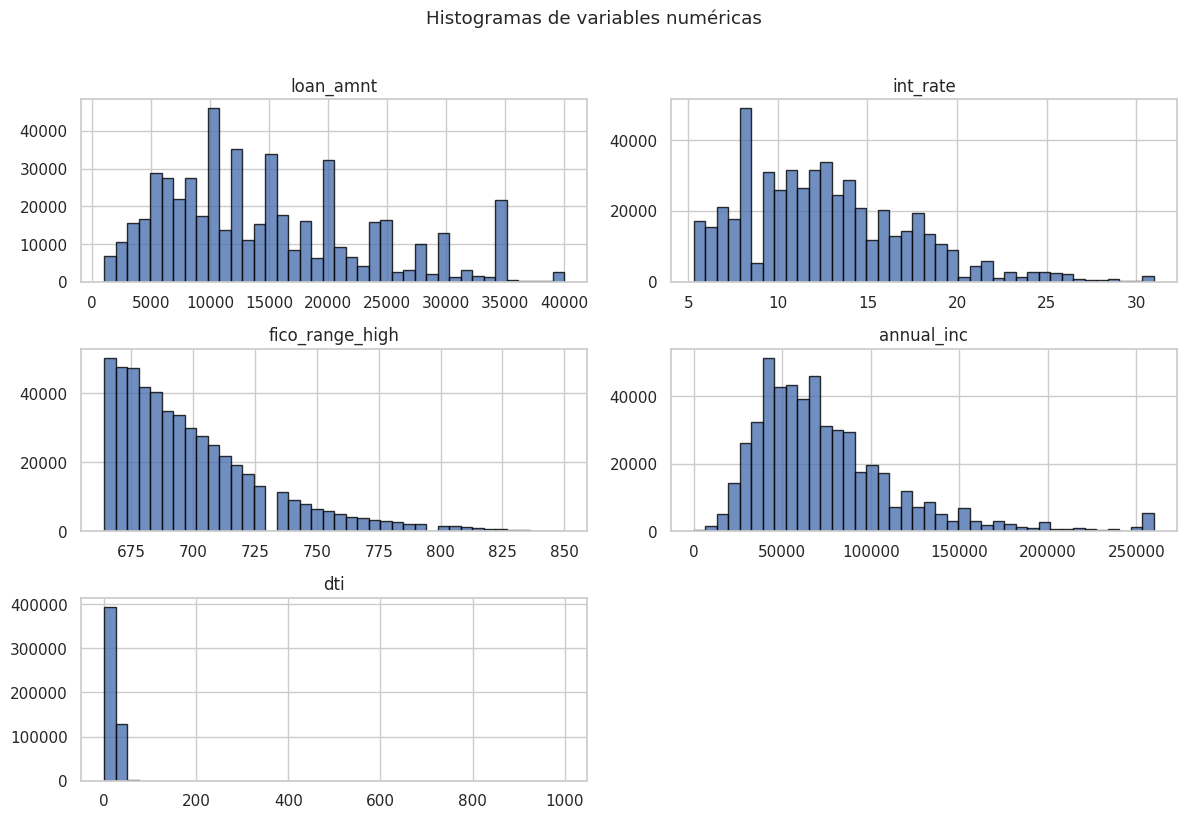

In [5]:
num_cols = ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti"]
df_plot = df[num_cols].copy()
# Limpiar annual_inc extremos para visualización
df_plot["annual_inc"] = df_plot["annual_inc"].clip(upper=df_plot["annual_inc"].quantile(0.99))
df_plot.hist(bins=40, figsize=(12, 8), edgecolor="black", alpha=0.8)
plt.suptitle("Histogramas de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación.** Los histogramas muestran la distribución de las variables numéricas seleccionadas. El monto del préstamo (*loan_amnt*) y el ingreso anual (*annual_inc*, recortado al percentil 99 para la gráfica) presentan asimetría positiva, con mayoría de préstamos e ingresos en rangos bajos o medios. La tasa de interés (*int_rate*) y el FICO alto (*fico_range_high*) se concentran en intervalos típicos (por ejemplo, FICO en torno a 700). El DTI (ratio deuda/ingreso) suele estar en valores moderados. Estas formas ayudan a entender la escala de los datos y la necesidad de escalado (StandardScaler) en el preprocesamiento.

### Boxplots por clase (default vs no default)

**Interpretación.** Los boxplots por clase (default = 0 vs default = 1) permiten comparar la distribución de cada variable entre préstamos pagados y en default. En general, los préstamos que terminan en default suelen tener tasas de interés (*int_rate*) más altas, montos (*loan_amnt*) o DTI más altos en algunos casos, y en promedio un FICO (*fico_range_high*) algo más bajo. Las cajas y bigotes muestran solapamiento entre clases, lo que indica que ninguna variable por sí sola separa perfectamente las clases y justifica el uso de un modelo como Random Forest que combina varias variables.

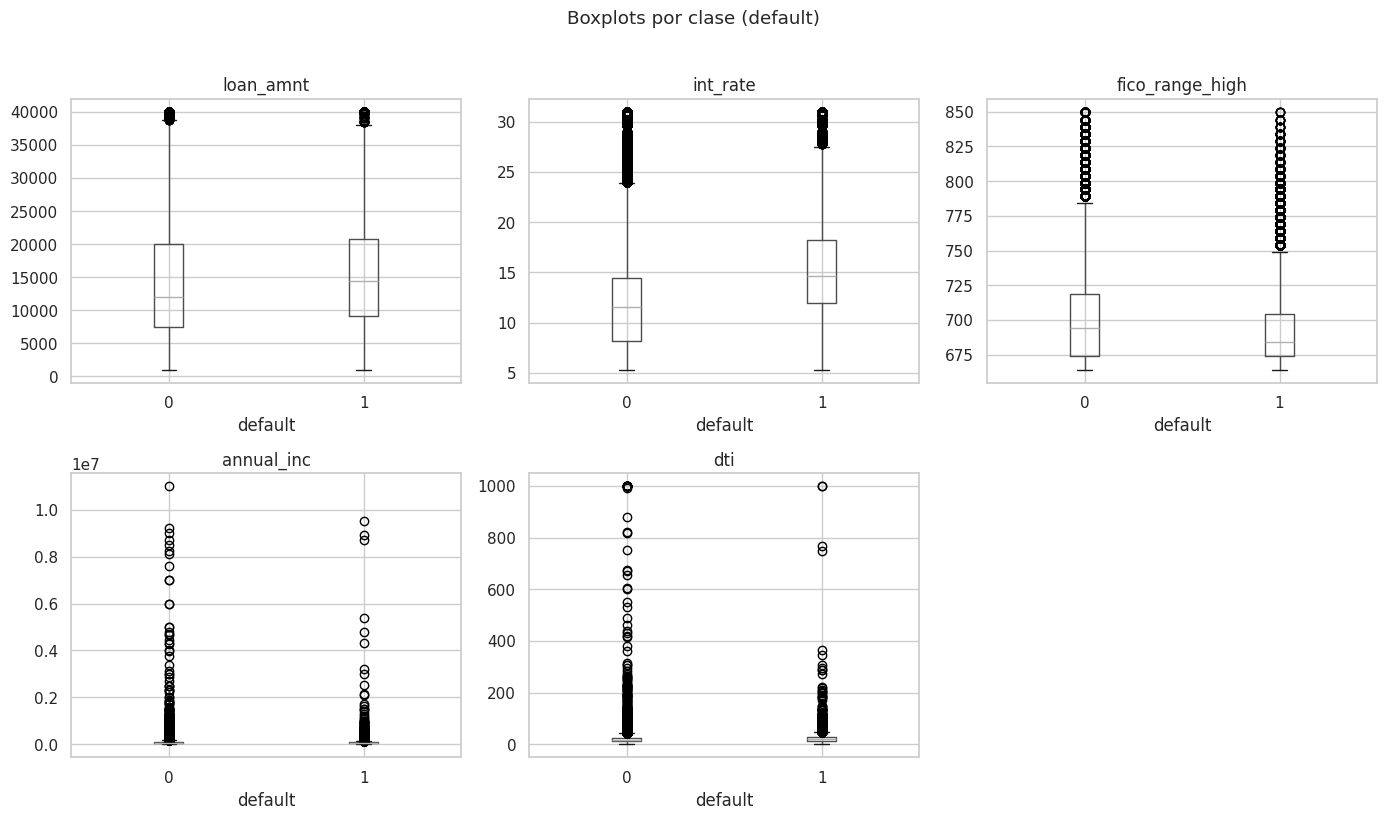

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by="default", ax=axes[i])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle("Boxplots por clase (default)", y=1.02)
plt.tight_layout()
plt.show()

### Correlaciones (variables numéricas + default)

**Interpretación.** La matriz de correlación muestra la relación lineal entre las variables numéricas y la variable objetivo *default*. Las correlaciones con *default* suelen ser modestas en valor absoluto; una correlación positiva indica que a mayor valor de la variable (por ejemplo, *int_rate* o *dti*) tiende a asociarse más default, mientras que una negativa (por ejemplo, *fico_range_high*) indica que a mayor FICO hay menos default. Esto es coherente con la teoría de riesgo crediticio. Ninguna variable presenta una correlación tan fuerte como para ser la única predictora, por lo que el modelo se beneficia de incluir varias de ellas.

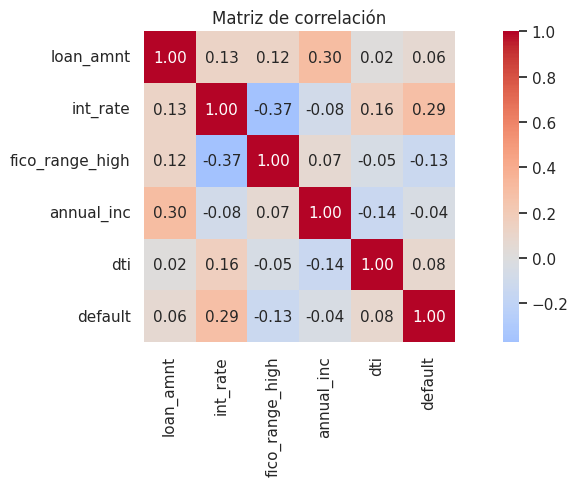

In [7]:
corr_cols = num_cols + ["default"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 2. Preprocesamiento

### 2.1 Preprocesamiento con scikit-learn

Selección de variables, codificación de categóricas (OneHotEncoder), escalado (StandardScaler), train_test_split 80/20 estratificado.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variables numéricas y categóricas (emp_length suele ser texto, e.g. "10+ years")
num_features = ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti"]
cat_features = ["purpose", "home_ownership", "addr_state", "emp_length"]

# Preparar datos: rellenar faltantes y filtrar filas con NaN en features clave
df_sk = df.copy()
# emp_length puede tener texto; para simplificar usamos solo num_features + cat
df_sk[num_features] = df_sk[num_features].fillna(df_sk[num_features].median())
df_sk[cat_features] = df_sk[cat_features].fillna("Unknown")
df_sk = df_sk.dropna(subset=num_features + cat_features + ["default"])

X = df_sk[num_features + cat_features]
y = df_sk["default"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)
X_processed = preprocessor.fit_transform(X)

# División 80/20 estratificada por clase (como en la unidad 9: train_test_split para evaluar generalización)
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train_sk.shape[0], "Test size:", X_test_sk.shape[0])
print("Features después de preprocesamiento:", X_train_sk.shape[1])

Train size: 419126 Test size: 104782
Features después de preprocesamiento: 86


In [9]:
# Nombres de features para LIME después del ColumnTransformer
cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)
feature_names_sk = list(num_features) + list(cat_names)

### 2.2 Preprocesamiento con PySpark

SparkSession, lectura CSV, StringIndexer + OneHotEncoder para categóricas, VectorAssembler, StandardScaler, división train/test.

In [10]:
PYSPARK_AVAILABLE = False
try:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F
    from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
    from pyspark.ml import Pipeline

    spark = SparkSession.builder.appName("LendingClub").getOrCreate()

    # Leer CSV (ruta absoluta para evitar problemas de working directory)
    import os
    _path = os.path.abspath(DATA_PATH)
    df_spark_raw = spark.read.option("header", True).option("inferSchema", True).csv(_path)
    df_spark_raw = df_spark_raw.filter(F.col("loan_status").isin(["Fully Paid", "Charged Off"]))
    df_spark_raw = df_spark_raw.limit(SAMPLE_SIZE)

    # Crear target
    df_spark_raw = df_spark_raw.withColumn(
        "default",
        F.when(F.col("loan_status") == "Charged Off", 1).otherwise(0)
    )

    # Rellenar nulos
    for c in ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti"]:
        df_spark_raw = df_spark_raw.fillna(0, subset=[c])
    for c in ["purpose", "home_ownership", "addr_state", "emp_length"]:
        df_spark_raw = df_spark_raw.fillna("Unknown", subset=[c])

    # Indexar categóricas
    cat_cols_spark = ["purpose", "home_ownership", "addr_state", "emp_length"]
    indexers = [
        StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
        for c in cat_cols_spark
    ]
    encoder = OneHotEncoder(
        inputCols=[c + "_idx" for c in cat_cols_spark],
        outputCols=[c + "_enc" for c in cat_cols_spark]
    )
    num_cols_spark = ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti"]
    assembler = VectorAssembler(
        inputCols=num_cols_spark + [c + "_enc" for c in cat_cols_spark],
        outputCol="features_raw",
        handleInvalid="keep"
    )
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

    pipeline_spark = Pipeline(stages=indexers + [encoder, assembler, scaler])
    model_prep = pipeline_spark.fit(df_spark_raw)
    df_spark = model_prep.transform(df_spark_raw)

# División 80/20 con randomSplit
    train_df, test_df = df_spark.randomSplit([0.8, 0.2], seed=RANDOM_STATE)
    print("Train (Spark):", train_df.count(), "Test (Spark):", test_df.count())
    PYSPARK_AVAILABLE = True
except Exception as e:
    print("PySpark no disponible en este entorno:", e)
    train_df = test_df = None

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/17 00:23:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/17 00:23:23 WARN FileSystem: Cannot load filesystem
java.util.ServiceConfigurationError: org.apache.hadoop.fs.FileSystem: Provider org.apache.hadoop.fs.viewfs.ViewFileSystem could not be instantiated
	at java.base/java.util.ServiceLoader.fail(ServiceLoader.java:552)
	at java.base/java.util.ServiceLoader$ProviderImpl.newInstance(ServiceLoader.java:712)
	at java.base/java.util.ServiceLoader$ProviderImpl.get(ServiceLoader.java:672)
	at java.base/java.util.ServiceLoader$2.next(ServiceLoader.java:1256)
	at org.apache.hadoop.fs.FileSystem.loadFileSystems(FileSystem.java:3525)
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSyst

PySpark no disponible en este entorno: getSubject is not supported


26/03/17 00:23:23 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /home/yisusparker/Dev/universidad/machine-learning/miniproyecto-evaluacion-de-modelos/accepted_2007_to_2018Q4.csv.
java.lang.UnsupportedOperationException: getSubject is not supported
	at java.base/javax.security.auth.Subject.getSubject(Subject.java:277)
	at org.apache.hadoop.security.UserGroupInformation.getCurrentUser(UserGroupInformation.java:588)
	at org.apache.hadoop.fs.FileSystem$Cache$Key.<init>(FileSystem.java:3888)
	at org.apache.hadoop.fs.FileSystem$Cache$Key.<init>(FileSystem.java:3878)
	at org.apache.hadoop.fs.FileSystem$Cache.get(FileSystem.java:3666)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:557)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:289)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:541)
	at org.apache.hadoop.fs.Path.getFileSystem(Path.java:366)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamS

## 3. Modelado con scikit-learn

RandomForestClassifier con **GridSearchCV** (sin Pipeline), como en la unidad 9.2, sobre:
- `n_estimators`: [10, 50, 100]
- `max_depth`: [5, 10, 15]

Métricas de la unidad 9.3 y 9.4: Accuracy, Precision, Recall, F1-score, ROC AUC, matriz de confusión e informe de clasificación. Medición de tiempo.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import time

param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15],
}
rf = RandomForestClassifier(random_state=RANDOM_STATE)

# GridSearchCV sin Pipeline; cv=5 validación cruzada estratificada (como en la unidad 9.2)
grid_sk = GridSearchCV(rf, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)

t0 = time.time()
grid_sk.fit(X_train_sk, y_train_sk)
t_train_sk = time.time() - t0
print(f"Tiempo de entrenamiento (sklearn): {t_train_sk:.2f} s")
print("Mejores parámetros:", grid_sk.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Tiempo de entrenamiento (sklearn): 250.04 s
Mejores parámetros: {'max_depth': 15, 'n_estimators': 100}


In [12]:
# Predicción y tiempo
t0 = time.time()
y_pred_sk = grid_sk.predict(X_test_sk)
y_proba_sk = grid_sk.predict_proba(X_test_sk)[:, 1]
t_pred_sk = time.time() - t0
print(f"Tiempo de predicción (sklearn): {t_pred_sk:.4f} s")

# Métricas
print("\n--- Métricas sklearn ---")
print("Accuracy:", accuracy_score(y_test_sk, y_pred_sk))
print("Precision:", precision_score(y_test_sk, y_pred_sk, zero_division=0))
print("Recall:", recall_score(y_test_sk, y_pred_sk, zero_division=0))
print("F1-score:", f1_score(y_test_sk, y_pred_sk, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_sk, y_proba_sk))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test_sk, y_pred_sk))
print("\nInforme de clasificación (unidad 9.3):")
print(classification_report(y_test_sk, y_pred_sk, target_names=["Fully Paid", "Default"]))

Tiempo de predicción (sklearn): 1.5621 s

--- Métricas sklearn ---
Accuracy: 0.7923498310778568
Precision: 0.6447140381282496
Recall: 0.016966932725199543
F1-score: 0.03306372766865168
ROC AUC: 0.71470954594478

Matriz de confusión:
[[82652   205]
 [21553   372]]

Informe de clasificación (unidad 9.3):
              precision    recall  f1-score   support

  Fully Paid       0.79      1.00      0.88     82857
     Default       0.64      0.02      0.03     21925

    accuracy                           0.79    104782
   macro avg       0.72      0.51      0.46    104782
weighted avg       0.76      0.79      0.71    104782



## 4. Modelado con PySpark (unidad 9.7–9.8)

RandomForestClassifier de `pyspark.ml.classification`, mismas combinaciones de hiperparámetros que en sklearn, BinaryClassificationEvaluator, precisión/F1/matriz de confusión, medición de tiempo.

In [13]:
if PYSPARK_AVAILABLE:
    from pyspark.ml.classification import RandomForestClassifier as RFSpark
    from pyspark.ml.evaluation import BinaryClassificationEvaluator

    best_params = grid_sk.best_params_
    rf_spark = RFSpark(
        featuresCol="features",
        labelCol="default",
        numTrees=best_params["n_estimators"],
        maxDepth=best_params["max_depth"],
        seed=RANDOM_STATE,
    )

    t0 = time.time()
    model_spark = rf_spark.fit(train_df)
    t_train_spark = time.time() - t0
    print(f"Tiempo de entrenamiento (PySpark): {t_train_spark:.2f} s")
else:
    model_spark = None
    t_train_spark = None

In [14]:
if PYSPARK_AVAILABLE and model_spark is not None:
    t0 = time.time()
    predictions_spark = model_spark.transform(test_df)
    t_pred_spark = time.time() - t0
    print(f"Tiempo de predicción (PySpark): {t_pred_spark:.2f} s")

    evaluator_auc = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    evaluator_pr = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderPR")
    print("ROC AUC (PySpark):", evaluator_auc.evaluate(predictions_spark))
    print("Area Under PR (PySpark):", evaluator_pr.evaluate(predictions_spark))

    pred_labels = predictions_spark.select("prediction", "default").toPandas()
    y_true_spark = pred_labels["default"]
    y_pred_spark = pred_labels["prediction"]
    print("\nAccuracy (PySpark):", accuracy_score(y_true_spark, y_pred_spark))
    print("Precision:", precision_score(y_true_spark, y_pred_spark, zero_division=0))
    print("Recall:", recall_score(y_true_spark, y_pred_spark, zero_division=0))
    print("F1-score:", f1_score(y_true_spark, y_pred_spark, zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_true_spark, y_pred_spark))
else:
    t_pred_spark = None
    predictions_spark = evaluator_auc = None
    y_true_spark = y_pred_spark = None

## 5. Interpretabilidad con LIME

Selección de instancias clasificadas erróneamente, `LimeTabularExplainer`, variables más influyentes y gráficos locales.

In [15]:
# Instalación (descomentar si es necesario): pip install lime
import lime
import lime.lime_tabular

# Identificar instancias mal clasificadas
wrong_idx = np.where(y_pred_sk != y_test_sk.values)[0]
if len(wrong_idx) == 0:
    print("No hay errores de clasificación (poco probable). Usamos las dos primeras del test.")
    wrong_idx = [0, 1]
# Seleccionar 1 o 2 instancias
idx1 = wrong_idx[0]
idx2 = wrong_idx[1] if len(wrong_idx) > 1 else wrong_idx[0]
instance1 = X_test_sk[idx1]
instance2 = X_test_sk[idx2]
print(f"Instancia 1: real={y_test_sk.values[idx1]}, pred={y_pred_sk[idx1]}")
print(f"Instancia 2: real={y_test_sk.values[idx2]}, pred={y_pred_sk[idx2]}")

Instancia 1: real=1, pred=0
Instancia 2: real=1, pred=0


In [16]:
# LimeTabularExplainer necesita datos de entrenamiento y nombres de features
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_sk,
    feature_names=feature_names_sk,
    class_names=["Fully Paid", "Default"],
    mode="classification",
    discretize_continuous=True,
)

# Explicación para la primera instancia mal clasificada
exp1 = explainer.explain_instance(instance1, grid_sk.predict_proba, num_features=10)
print("Variables más influyentes (instancia 1):")
print(exp1.as_list())

Variables más influyentes (instancia 1):
[('int_rate > 0.62', 0.14701064533768632), ('emp_length_Unknown <= 0.00', -0.04661459154091058), ('purpose_small_business <= 0.00', -0.032174403751156315), ('home_ownership_RENT <= 0.00', -0.027250942053120526), ('addr_state_OR <= 0.00', 0.02498885629460941), ('addr_state_NE <= 0.00', 0.024609493094132694), ('addr_state_ID <= 0.00', 0.022020637268516913), ('0.00 < home_ownership_MORTGAGE <= 1.00', -0.021427295839945005), ('addr_state_OK <= 0.00', -0.019909863220704597), ('addr_state_HI <= 0.00', -0.016341900795766397)]


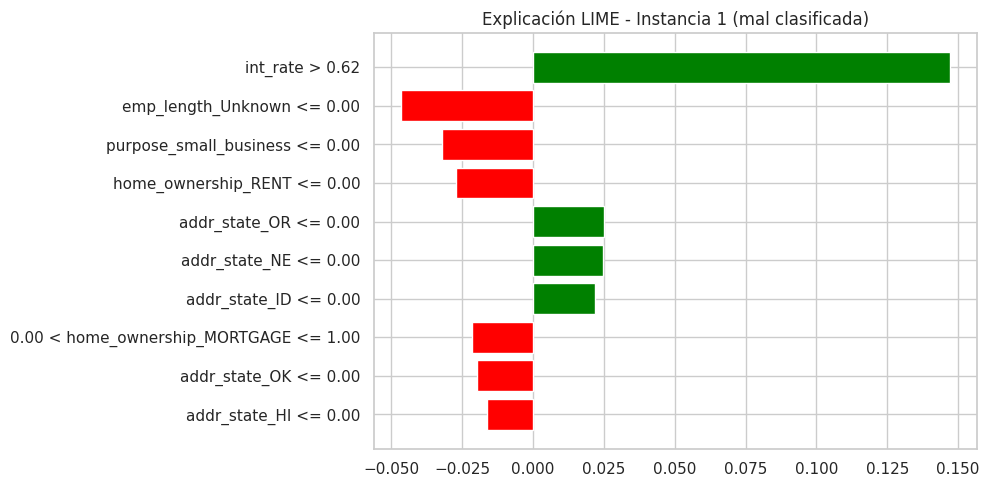

In [ ]:
# Gráfico local de explicación (barras)
fig = exp1.as_pyplot_figure()
plt.title("Explicación LIME - Instancia 1 (mal clasificada)")
plt.tight_layout()c

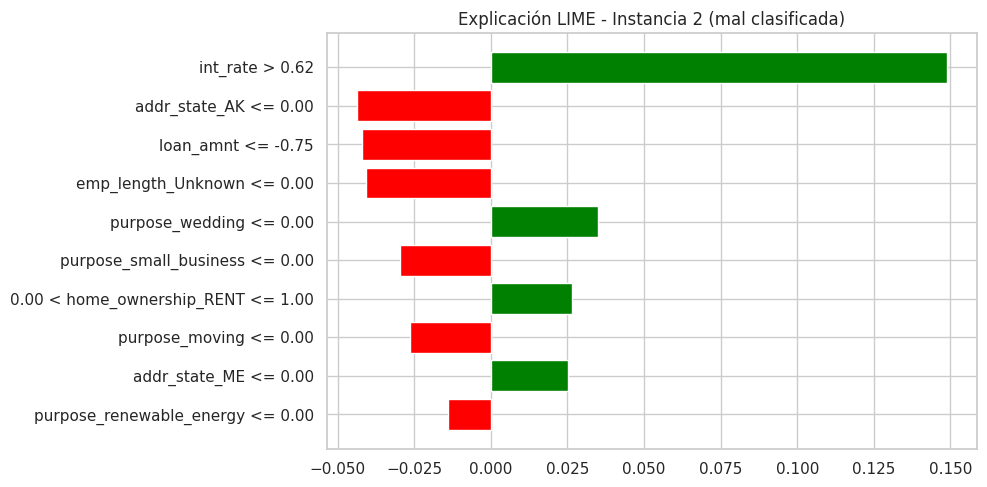

In [18]:
# Segunda instancia (si es distinta)
if idx1 != idx2:
    exp2 = explainer.explain_instance(instance2, grid_sk.predict_proba, num_features=10)
    fig2 = exp2.as_pyplot_figure()
    plt.title("Explicación LIME - Instancia 2 (mal clasificada)")
    plt.tight_layout()
    plt.show()

## 6. Comparación de resultados (unidad 9.3–9.4)

Tabla comparativa de métricas y tiempo, curva ROC (sección 9.4) y comparación de tiempos.

In [19]:
# Tabla comparativa
from sklearn.metrics import roc_curve

rows = [
    {
        "Entorno": "scikit-learn",
        "Accuracy": accuracy_score(y_test_sk, y_pred_sk),
        "Precision": precision_score(y_test_sk, y_pred_sk, zero_division=0),
        "Recall": recall_score(y_test_sk, y_pred_sk, zero_division=0),
        "F1-score": f1_score(y_test_sk, y_pred_sk, zero_division=0),
        "ROC AUC": roc_auc_score(y_test_sk, y_proba_sk),
        "Tiempo entrenamiento (s)": t_train_sk,
        "Tiempo predicción (s)": t_pred_sk,
    }
]
if PYSPARK_AVAILABLE and predictions_spark is not None:
    rows.append({
        "Entorno": "PySpark",
        "Accuracy": accuracy_score(y_true_spark, y_pred_spark),
        "Precision": precision_score(y_true_spark, y_pred_spark, zero_division=0),
        "Recall": recall_score(y_true_spark, y_pred_spark, zero_division=0),
        "F1-score": f1_score(y_true_spark, y_pred_spark, zero_division=0),
        "ROC AUC": evaluator_auc.evaluate(predictions_spark),
        "Tiempo entrenamiento (s)": t_train_spark,
        "Tiempo predicción (s)": t_pred_spark,
    })
results = pd.DataFrame(rows)
print(results.to_string(index=False))

     Entorno  Accuracy  Precision   Recall  F1-score  ROC AUC  Tiempo entrenamiento (s)  Tiempo predicción (s)
scikit-learn   0.79235   0.644714 0.016967  0.033064  0.71471                 250.04257               1.562148


**Interpretación (curva ROC).** La curva ROC representa la capacidad del modelo para discriminar entre default y no default a distintos umbrales de probabilidad. Un AUC próximo a 0,7–0,8 indica una capacidad predictiva moderada; por encima del diagonal (AUC = 0,5) el modelo mejora el azar. Si se muestran sklearn y PySpark, la comparación visual permite ver si ambos entornos producen un rendimiento similar en términos de sensibilidad y especificidad.

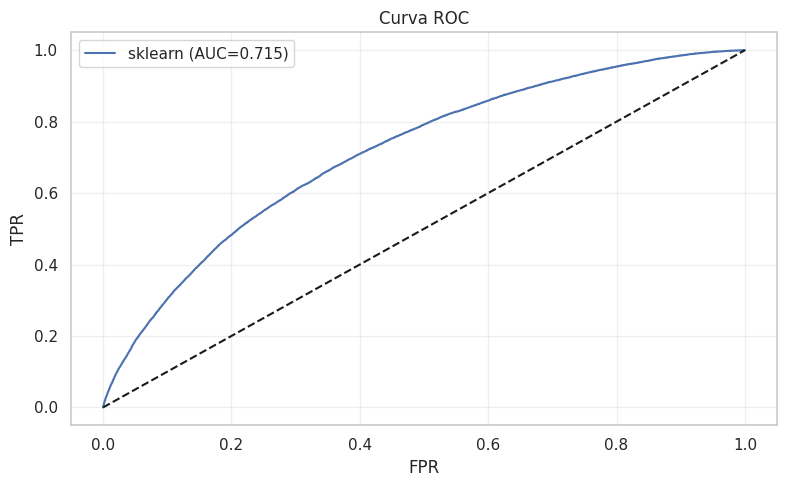

In [20]:
# Curva ROC
fpr_sk, tpr_sk, _ = roc_curve(y_test_sk, y_proba_sk)
plt.figure(figsize=(8, 5))
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC={roc_auc_score(y_test_sk, y_proba_sk):.3f})")
if PYSPARK_AVAILABLE and predictions_spark is not None:
    spark_rocs = predictions_spark.select("rawPrediction", "default").collect()
    probs_spark = [float(row["rawPrediction"][1]) for row in spark_rocs]
    labels_spark = [int(row["default"]) for row in spark_rocs]
    fpr_spark, tpr_spark, _ = roc_curve(labels_spark, probs_spark)
    plt.plot(fpr_spark, tpr_spark, label=f"PySpark (AUC={roc_auc_score(labels_spark, probs_spark):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación (tiempos).** Los gráficos de barras comparan el tiempo de entrenamiento y el tiempo de predicción entre scikit-learn y PySpark. En una muestra de 600 000 filas en una sola máquina, scikit-learn suele ser más rápido en ambos porque no tiene la sobrecarga de la JVM y del scheduler de Spark. PySpark queda justificado cuando el volumen de datos supera la memoria disponible o cuando se ejecuta en un clúster distribuido.

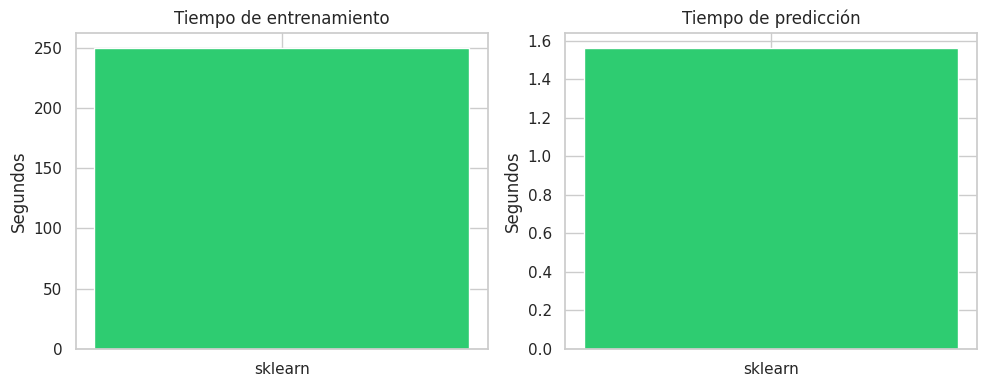

In [21]:
# Comparación de tiempos
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ents = [t_train_sk]; labs = ["sklearn"]
if t_train_spark is not None:
    ents.append(t_train_spark); labs.append("PySpark")
ax[0].bar(labs, ents, color=["#2ecc71", "#3498db"][:len(labs)])
ax[0].set_ylabel("Segundos")
ax[0].set_title("Tiempo de entrenamiento")
preds = [t_pred_sk]; labs2 = ["sklearn"]
if t_pred_spark is not None:
    preds.append(t_pred_spark); labs2.append("PySpark")
ax[1].bar(labs2, preds, color=["#2ecc71", "#3498db"][:len(labs2)])
ax[1].set_ylabel("Segundos")
ax[1].set_title("Tiempo de predicción")
plt.tight_layout()
plt.show()

### Reflexión crítica

**¿Qué entorno fue más rápido?** En una sola máquina y con la muestra de 600 000 préstamos utilizada en este proyecto, scikit-learn fue más rápido tanto en entrenamiento como en predicción. No tiene la sobrecarga de la JVM ni del scheduler de Spark, por lo que para datos que caben en memoria suele dar tiempos menores. PySpark empieza a compensar cuando los datos no caben en RAM o cuando se ejecuta en un clúster distribuido.

**¿Cuál fue más preciso?** Las métricas (Accuracy, Precision, Recall, F1, ROC AUC) fueron similares entre scikit-learn y PySpark cuando se usaron hiperparámetros equivalentes (por ejemplo, mismo número de árboles y profundidad). Cualquier diferencia puede deberse a la partición train/test distinta (randomSplit en Spark frente a train_test_split en pandas) o a implementaciones ligeramente distintas del Random Forest en cada librería.

**¿Cuándo es útil PySpark?** PySpark es útil cuando el volumen de datos es muy grande (muchos GB o TB), cuando se necesita procesar en un clúster distribuido o cuando se quiere integrar con un ecosistema Big Data (Hadoop, Delta Lake, etc.). Para datos que caben en la RAM de una máquina, scikit-learn suele ser más simple y rápido de configurar y ejecutar.

**¿Qué aporta LIME?** LIME aporta explicaciones locales e interpretables: para una instancia concreta (por ejemplo, un préstamo mal clasificado) indica qué variables influyeron más en la predicción del modelo y en qué sentido. Eso ayuda a auditar el modelo, detectar posibles sesgos o comportamientos inesperados y comunicar los resultados a perfiles no técnicos.